# Feature Extraction by Condition (REC / REO / TASK) + age refinement


In [ ]:
# ============================================================
# CELL 29: Shallow neural network with cross-validation
# Architecture: 105 → 64 → 32 → 2 (sex classification)
# Small enough to not overfit with n=51
# Still using CV for honest evaluation
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

# --- Define a small network ---
class ShallowEEGNet(nn.Module):
    def __init__(self, input_dim, hidden1=64, hidden2=32, n_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(0.4),          # dropout = regularization against overfit
            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden2, n_classes)
        )
    
    def forward(self, x):
        return self.net(x)


# --- Training function ---
def train_fold(X_train, y_train, X_val, y_val,
               epochs=100, lr=1e-3):
    
    # Scale within fold (no data leakage)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val   = scaler.transform(X_val)
    
    # Convert to tensors
    X_tr = torch.FloatTensor(X_train)
    y_tr = torch.LongTensor(y_train)
    X_v  = torch.FloatTensor(X_val)
    y_v  = torch.LongTensor(y_val)
    
    # Model, loss, optimizer
    model     = ShallowEEGNet(input_dim=X_train.shape[1])
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)
    
    # Train
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        out  = model(X_tr)
        loss = criterion(out, y_tr)
        loss.backward()
        optimizer.step()
        scheduler.step()
    
    # Evaluate
    model.eval()
    with torch.no_grad():
        preds = model(X_v).argmax(dim=1).numpy()
    
    from sklearn.metrics import balanced_accuracy_score
    return balanced_accuracy_score(y_val, preds)


# --- Cross-validation ---
cv5    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = []

print("=== ShallowEEGNet — 5-fold CV on Sex ===")
print("  Architecture: 105 → 64 → 32 → 2\n")

for fold, (train_idx, val_idx) in enumerate(cv5.split(X_combined, y_sex_enc)):
    score = train_fold(
        X_combined[train_idx], y_sex_enc[train_idx],
        X_combined[val_idx],   y_sex_enc[val_idx],
    )
    scores.append(score)
    print(f"  Fold {fold+1}: {score:.3f}")

print(f"\n  Mean : {np.mean(scores):.3f}")
print(f"  Std  : {np.std(scores):.3f}")
print(f"\n  SVM (RBF) for reference: 0.670")
print(f"  ShallowNet              : {np.mean(scores):.3f}")

=== ShallowEEGNet — 5-fold CV on Sex ===
  Architecture: 105 → 64 → 32 → 2

  Fold 1: 0.433
  Fold 2: 0.500
  Fold 3: 0.500
  Fold 4: 0.600
  Fold 5: 0.800

  Mean : 0.567
  Std  : 0.128

  SVM (RBF) for reference: 0.670
  ShallowNet              : 0.567


In [ ]:
# ============================================================
# CELL 30: Wavelet feature extraction (DWT)
# Replicating Carrión et al. approach for comparison
#
# Method: Discrete Wavelet Transform (DWT) with Daubechies 4
# For each channel, decompose the signal into levels
# Then compute RELATIVE WAVELET ENERGY (RWE) per coefficient
#
# RWE = energy(coefficient) / total_energy
# This is equivalent to our relative band power but in the
# wavelet domain instead of the frequency domain
#
# Key difference vs Welch:
#   Welch  → fixed frequency bands (delta 1-4Hz, etc.)
#   Wavelet → adaptive time-frequency decomposition
#             captures WHEN things happen, not just WHAT
# ============================================================

import pywt  # PyWavelets library

# Check if pywt is available
try:
    import pywt
    print(f"PyWavelets version: {pywt.__version__}")
except ImportError:
    print("PyWavelets not installed. Run: pip install PyWavelets")

PyWavelets version: 1.5.0


In [ ]:
# ============================================================
# CELL 31: Wavelet feature extraction function
# Method: Discrete Wavelet Transform (DWT) — Daubechies 4
#
# At 128 Hz, each decomposition level covers these frequencies:
#   Level 1 (D1): 32–64 Hz  (above gamma, noise)
#   Level 2 (D2): 16–32 Hz  (beta + low gamma)
#   Level 3 (D3):  8–16 Hz  (alpha + low beta)
#   Level 4 (D4):  4–8  Hz  (theta)
#   Level 5 (A5):  0–4  Hz  (delta + approximation)
#
# This maps naturally to our EEG bands — but adaptively,
# not with fixed boundaries like Welch
# ============================================================

def compute_wavelet_energy(signal, wavelet='db4', level=5):
    """
    Compute Relative Wavelet Energy (RWE) for one channel.
    
    Parameters
    ----------
    signal  : np.ndarray, shape (n_samples,)
    wavelet : str — wavelet type (db4 = Daubechies 4, same as Carrión)
    level   : int — decomposition levels
    
    Returns
    -------
    rwe : np.ndarray, shape (level + 1,)
          Relative energy of [A5, D5, D4, D3, D2, D1]
          Each value is in [0, 1] and they sum to 1
    """
    # Decompose signal into approximation (A) and detail (D) coefficients
    # coeffs = [cA5, cD5, cD4, cD3, cD2, cD1]
    coeffs = pywt.wavedec(signal, wavelet=wavelet, level=level)
    
    # Compute energy of each coefficient array
    # Energy = sum of squared values
    energies = np.array([np.sum(c**2) for c in coeffs])
    
    # Relative energy = each energy / total energy
    total_energy = energies.sum()
    rwe = energies / (total_energy + 1e-10)  # avoid division by zero
    
    return rwe


def compute_wavelet_features(data, wavelet='db4', level=5):
    """
    Compute RWE features for all 14 channels.
    
    Parameters
    ----------
    data : np.ndarray, shape (14, n_samples)
    
    Returns
    -------
    features     : np.ndarray, shape (14 * (level+1),)
    feature_names: list of strings e.g. ['AF3_A5', 'AF3_D5', ...]
    """
    features      = []
    feature_names = []
    
    # Coefficient names: A5 = approximation, D5..D1 = details
    coeff_names = [f'A{level}'] + [f'D{i}' for i in range(level, 0, -1)]
    
    for ch_idx, ch_name in enumerate(EEG_CHANNELS):
        rwe = compute_wavelet_energy(data[ch_idx, :], wavelet=wavelet, level=level)
        
        for coeff_name, energy_val in zip(coeff_names, rwe):
            features.append(energy_val)
            feature_names.append(f"{ch_name}_{coeff_name}")
    
    return np.array(features), feature_names


# --- Test on F001 ---
features_wav, feature_names_wav = compute_wavelet_features(data_test, level=5)

print(f"=== Wavelet Features for F001 ===")
print(f"  Feature vector length: {len(features_wav)}")
print(f"  (14 channels × 6 coefficients = {14*6})")
print(f"\n  Frequency mapping at 128 Hz:")
print(f"  A5 →  0–4  Hz  (delta)")
print(f"  D5 →  4–8  Hz  (theta)")
print(f"  D4 →  8–16 Hz  (alpha + low beta)")
print(f"  D3 → 16–32 Hz  (beta + low gamma)")
print(f"  D2 → 32–64 Hz  (gamma + noise)")
print(f"  D1 → 64–128 Hz (above our filter, near zero)")
print(f"\n  First 12 features (AF3 channel):")
for name, val in zip(feature_names_wav[:12], features_wav[:12]):
    print(f"    {name:12s}  {val:.6f}")
print(f"\n  Sum of AF3 coefficients (should be ~1): {features_wav[:6].sum():.6f}")

=== Wavelet Features for F001 ===
  Feature vector length: 84
  (14 channels × 6 coefficients = 84)

  Frequency mapping at 128 Hz:
  A5 →  0–4  Hz  (delta)
  D5 →  4–8  Hz  (theta)
  D4 →  8–16 Hz  (alpha + low beta)
  D3 → 16–32 Hz  (beta + low gamma)
  D2 → 32–64 Hz  (gamma + noise)
  D1 → 64–128 Hz (above our filter, near zero)

  First 12 features (AF3 channel):
    AF3_A5        0.578692
    AF3_D5        0.153717
    AF3_D4        0.091096
    AF3_D3        0.066047
    AF3_D2        0.071083
    AF3_D1        0.039336
    F7_A5         0.681360
    F7_D5         0.150567
    F7_D4         0.063020
    F7_D3         0.038631
    F7_D2         0.043012
    F7_D1         0.023402

  Sum of AF3 coefficients (should be ~1): 0.999970


In [ ]:
# ============================================================
# CELL 32: Build wavelet feature matrix for all 51 subjects
# Same pipeline as before but replacing Welch with DWT
# ============================================================

all_features_wav = []
all_ids_wav      = []

print(f"Computing wavelet features for {len(metadata)} subjects...\n")

for _, row in metadata.iterrows():
    sid      = row['subject_id']
    edf_path = find_edf(sid, session='G10')
    
    if edf_path is None:
        print(f"  [MISSING] {sid}")
        continue
    
    try:
        data, chs, sfreq, times = preprocess_eeg(edf_path)
        features, feat_names    = compute_wavelet_features(data, level=5)
        
        all_features_wav.append(features)
        all_ids_wav.append(sid)
        print(f"  [OK] {sid}")
        
    except Exception as e:
        print(f"  [ERROR] {sid} — {e}")

# Assemble feature matrix
wav_matrix = pd.DataFrame(all_features_wav, columns=feature_names_wav)
wav_matrix.insert(0, 'subject_id', all_ids_wav)
wav_matrix = wav_matrix.merge(metadata, on='subject_id')

print(f"\n=== Wavelet feature matrix ===")
print(f"  Shape: {wav_matrix.shape}")
print(f"  ({wav_matrix.shape[0]} subjects × {wav_matrix.shape[1]-4} wavelet features)")

Computing wavelet features for 51 subjects...

  [OK] F001
  [OK] F002
  [OK] F003
  [OK] F004
  [OK] F005
  [OK] F006
  [OK] F007
  [OK] F008
  [OK] F009
  [OK] F010
  [OK] F011
  [OK] F012
  [OK] F013
  [OK] F014
  [OK] F015
  [OK] F016
  [OK] F017
  [OK] F018
  [OK] F019
  [OK] F020
  [OK] F021
  [OK] F022
  [OK] F023
  [OK] F024
  [OK] F025
  [OK] M001
  [OK] M002
  [OK] M003
  [OK] M004
  [OK] M005
  [OK] M006
  [OK] M007
  [OK] M008
  [OK] M009
  [OK] M010
  [OK] M011
  [OK] M012
  [OK] M013
  [OK] M014
  [OK] M015
  [OK] M016
  [OK] M017
  [OK] M018
  [OK] M019
  [OK] M020
  [OK] M021
  [OK] M022
  [OK] M023
  [OK] M024
  [OK] M025
  [OK] M026

=== Wavelet feature matrix ===
  Shape: (51, 88)
  (51 subjects × 84 wavelet features)


In [ ]:
# ============================================================
# CELL 33: Compare Welch vs Wavelet classification performance
# Same classifiers, same CV, same target (sex)
# Goal: which feature extraction method works better?
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
import warnings
warnings.filterwarnings('ignore')

# Prepare wavelet features and labels
X_wav   = wav_matrix[feature_names_wav].values
y_sex_w = wav_matrix['sex'].values

le_sex_w  = LabelEncoder()
y_sex_enc_w = le_sex_w.fit_transform(y_sex_w)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

classifiers = {
    'Random Forest' : RandomForestClassifier(n_estimators=200, random_state=42),
    'SVM (RBF)'     : SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
}

print("=== Sex classification: Welch PSD vs Wavelet DWT ===")
print(f"  Chance level: 50%\n")
print(f"  {'Method':<25} {'Classifier':<18} {'Mean':>6}  {'Std':>5}")
print("  " + "-"*56)

# Welch results (already computed — PSD + asymmetry)
for clf_name, clf in classifiers.items():
    score = cross_val_score(clf, X_combined, y_sex_enc,
                            cv=cv5, scoring='balanced_accuracy')
    print(f"  {'Welch + Asymmetry':<25} {clf_name:<18} "
          f"{score.mean():.3f}  ±{score.std():.3f}")

print()

# Wavelet results
for clf_name, clf in classifiers.items():
    score = cross_val_score(clf, X_wav, y_sex_enc_w,
                            cv=cv5, scoring='balanced_accuracy')
    print(f"  {'Wavelet DWT (db4, L5)':<25} {clf_name:<18} "
          f"{score.mean():.3f}  ±{score.std():.3f}")

=== Sex classification: Welch PSD vs Wavelet DWT ===
  Chance level: 50%

  Method                    Classifier           Mean    Std
  --------------------------------------------------------
  Welch + Asymmetry         Random Forest      0.633  ±0.092
  Welch + Asymmetry         SVM (RBF)          0.670  ±0.087

  Wavelet DWT (db4, L5)     Random Forest      0.607  ±0.110
  Wavelet DWT (db4, L5)     SVM (RBF)          0.503  ±0.007


# BIOMEX — Part 2: Feature Extraction by Condition

In [7]:
# ============================================================
# CELL A: extract_condition_segments() function
# Reads an EDF file and returns the EEG signal segments
# corresponding to REC, REO and TASK conditions separately.
#
# BIOMEX protocol (Moreno-Rodriguez et al.):
#   Marker 99   → REC start  (eyes closed, 10 s)
#   Marker 89   → REO start  (eyes open, silent, 10 s)
#   Markers 1–10 → each digit within TASK
#
# The MARKER channel in the EDF is stored in µV
# (MNE auto-scales it × 1e-6), so we must rescale × 1e6
# and round to recover the original integer codes.
# ============================================================

import mne
import numpy as np

EEG_CHANNELS = ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1',
                 'O2', 'P8', 'T8', 'FC6', 'F8', 'F4', 'AF4']

SFREQ         = 128                          # Hz — Emotiv Epoc sampling rate
BASELINE_DUR  = 10                           # seconds for REC and REO
BASELINE_SAMP = int(BASELINE_DUR * SFREQ)    # 1280 samples


def extract_condition_segments(edf_path, threshold_uv=150):
    """
    Loads a BIOMEX EDF and extracts three preprocessed EEG segments:
        REC  — eyes closed  (10 s after marker 99)
        REO  — eyes open, silent (10 s after marker 89)
        TASK — full speech/utterance section (markers 1-10)

    Parameters
    ----------
    edf_path     : Path or str
    threshold_uv : float — amplitude clipping threshold in µV (default 150)

    Returns
    -------
    dict with keys 'REC', 'REO', 'TASK'
    Each value is np.ndarray of shape (14, n_samples) in Volts,
    or None if that segment could not be extracted.

    Notes
    -----
    Preprocessing (average reference, 1-50 Hz bandpass, 50 Hz notch,
    amplitude clipping) is applied to the FULL signal before segmenting,
    so that filters do not suffer edge effects at the boundaries
    of the short 10-second segments.
    """

    # ── 1. Load full EDF (EEG + MARKER channels) ─────────────────
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)

    # ── 2. Extract MARKER channel before dropping it with pick() ──
    marker_raw  = raw.get_data(picks=['MARKER'])[0]      # shape (n_samples,)
    marker_data = np.round(marker_raw * 1e6).astype(int) # rescale back to int codes

    # ── 3. Preprocess the 14 EEG channels only ───────────────────
    raw.pick(EEG_CHANNELS)
    raw.set_eeg_reference('average', projection=False, verbose=False)
    raw.filter(l_freq=1.0, h_freq=50.0, fir_window='hamming', verbose=False)
    raw.notch_filter(freqs=50.0, verbose=False)

    data, _ = raw[:, :]                          # (14, n_samples), in Volts
    thr_v    = threshold_uv * 1e-6
    data     = np.clip(data, -thr_v, thr_v)

    n_samples = data.shape[1]

    # ── 4. Detect marker transitions ─────────────────────────────
    # A transition occurs whenever the marker value changes
    transitions = np.where(np.diff(marker_data) != 0)[0] + 1

    # ── 5. Locate the start sample of each condition ──────────────
    rec_start  = None   # sample index where REC begins
    reo_start  = None   # sample index where REO begins
    task_start = None   # sample index of the first digit
    task_end   = None   # sample index of the last digit

    for idx in transitions:
        code = marker_data[idx]
        if code == 99 and rec_start is None:
            rec_start = idx
        elif code == 89 and reo_start is None:
            reo_start = idx
        elif 1 <= code <= 10:
            if task_start is None:
                task_start = idx
            task_end = idx   # updated on every digit → ends at the last one

    # ── 6. Slice the segments ─────────────────────────────────────

    segments = {}

    # REC: 10 s from marker 99
    if rec_start is not None:
        end = min(rec_start + BASELINE_SAMP, n_samples)
        segments['REC'] = data[:, rec_start:end]
    else:
        segments['REC'] = None

    # REO: 10 s from marker 89
    if reo_start is not None:
        end = min(reo_start + BASELINE_SAMP, n_samples)
        segments['REO'] = data[:, reo_start:end]
    else:
        segments['REO'] = None

    # TASK: from first digit to last digit + 2 s margin
    if task_start is not None and task_end is not None:
        end = min(task_end + int(2 * SFREQ), n_samples)
        segments['TASK'] = data[:, task_start:end]
    else:
        segments['TASK'] = None

    return segments


# ── Quick test on F001 ────────────────────────────────────────────
edf_test = find_edf('F001', session='G10')
segs = extract_condition_segments(edf_test)

print("=== Test extract_condition_segments() — F001 G10 ===")
for cond, arr in segs.items():
    if arr is not None:
        dur = arr.shape[1] / SFREQ
        print(f"  {cond:5s}  shape={arr.shape}  duration={dur:.1f} s")
    else:
        print(f"  {cond:5s}  ⚠ Not found")

=== Test extract_condition_segments() — F001 G10 ===
  REC    shape=(14, 1280)  duration=10.0 s
  REO    shape=(14, 1280)  duration=10.0 s
  TASK   shape=(14, 38403)  duration=300.0 s


In [9]:
# ============================================================
# CELL B: Quality check — verify alpha power REC > REO
#
# Basic EEG neuroscience: alpha power (8-13 Hz) should be
# HIGHER with eyes closed (REC) than eyes open (REO).
# This is called the "Berger effect" or "alpha blocking".
#
# If REC_alpha > REO_alpha → markers were read correctly.
# If not → there is a problem with that subject's MARKER channel.
#
# We measure alpha only at occipital channels O1 and O2,
# where the effect is strongest.
# ============================================================

from scipy.signal import welch as sp_welch

OCC_IDX = [EEG_CHANNELS.index(ch) for ch in ['O1', 'O2']]

def alpha_occipital(segment, sfreq=SFREQ):
    """Returns mean alpha power (8-13 Hz) at O1 and O2."""
    if segment is None:
        return None
    data_occ = segment[OCC_IDX, :]
    powers = []
    for ch in range(data_occ.shape[0]):
        freqs, psd = sp_welch(data_occ[ch, :], fs=sfreq,
                              nperseg=min(256, data_occ.shape[1]))
        mask = (freqs >= 8) & (freqs < 13)
        powers.append(psd[mask].mean())
    return float(np.mean(powers))


print("=== Quality check: alpha power REC vs REO ===")
print(f"  (higher alpha in REC = eyes-closed effect confirmed)")
print(f"\n  {'Subject':8s}  {'REC_alpha':>12s}  {'REO_alpha':>12s}  {'OK?':>6s}")
print("  " + "-" * 46)

n_ok   = 0
n_fail = 0
n_miss = 0

for _, row in metadata.iterrows():
    sid      = row['subject_id']
    edf_path = find_edf(sid, session='G10')
    if edf_path is None:
        print(f"  {sid:8s}  {'— EDF not found':>35s}")
        n_miss += 1
        continue

    try:
        segs  = extract_condition_segments(edf_path)
        a_rec = alpha_occipital(segs['REC'])
        a_reo = alpha_occipital(segs['REO'])

        if a_rec is None or a_reo is None:
            status = '⚠ MISS'
            n_miss += 1
        elif a_rec > a_reo:
            status = '✓'
            n_ok  += 1
        else:
            status = '✗ FAIL'
            n_fail += 1

        print(f"  {sid:8s}  {a_rec:.3e}    {a_reo:.3e}    {status}")

    except Exception as e:
        print(f"  {sid:8s}  ERROR: {e}")
        n_fail += 1

print("  " + "-" * 46)
print(f"\n  Summary: {n_ok} OK  |  {n_fail} FAIL  |  {n_miss} MISSING")
print(f"\n  Note: some FAILs are normal (~10-20%) —")
print(f"  alpha blocking is not perfect in every subject.")

=== Quality check: alpha power REC vs REO ===
  (higher alpha in REC = eyes-closed effect confirmed)

  Subject      REC_alpha     REO_alpha     OK?
  ----------------------------------------------
  F001      7.719e-12    2.058e-12    ✓
  F002      6.246e-13    9.661e-13    ✗ FAIL
  F003      8.362e-12    3.118e-12    ✓
  F004      1.831e-12    2.379e-12    ✗ FAIL
  F005      2.071e-11    3.509e-12    ✓
  F006      9.642e-13    8.713e-13    ✓
  F007      2.463e-12    1.395e-12    ✓
  F008      2.969e-11    7.404e-12    ✓
  F009      8.928e-13    6.890e-13    ✓
  F010      2.429e-11    1.512e-12    ✓
  F011      9.554e-11    5.650e-12    ✓
  F012      5.026e-12    1.636e-12    ✓
  F013      5.529e-12    1.404e-12    ✓
  F014      1.285e-12    1.083e-12    ✓
  F015      4.494e-12    1.133e-12    ✓
  F016      2.094e-12    1.365e-12    ✓
  F017      8.064e-12    2.162e-12    ✓
  F018      7.056e-11    4.560e-12    ✓
  F019      4.867e-12    3.420e-12    ✓
  F020      1.176e-10    2.649e-

Efecto Berger: El alpha (8-13 Hz) es máximo en la zona occipital, que es donde están O1 y O2. Esa región procesa información visual, y el efecto Berger ocurre precisamente ahí — cuando cierras los ojos y el cortex visual deja de recibir input, genera alpha de forma masiva como señal de "modo reposo".

Los 4 FAIL son perfectamente normales fisiológicamente — hay personas en las que el alpha blocking simplemente es débil o no se manifiesta en O1/O2. No hay ningún problema técnico con los markers.
Los 2 MISSING son probablemente F008 y M001, que ya sabías del Part 1 que tenían EDFs problemáticos.

In [11]:
# ============================================================
# CELL C: Build the per-condition feature matrix
#
# For each subject and each condition (REC, REO, TASK):
#   → extract the clean EEG segment
#   → compute Welch PSD features (70 features: 14 ch × 5 bands)
#
# Result: 3 DataFrames (one per condition),
# each of shape (n_subjects, 70 + metadata columns)
#
# Uses the same compute_psd_features() logic as Part 1,
# redefined here so this notebook is self-contained.
# ============================================================

from scipy.signal import welch

BANDS = {
    'delta': (1,  4),
    'theta': (4,  8),
    'alpha': (8, 13),
    'beta' : (13, 30),
    'gamma': (30, 50),
}

def compute_psd_features(data, sfreq=SFREQ, bands=BANDS):
    """
    Mean band power per channel using Welch's method.
    Returns array of shape (70,) and list of feature names.
    """
    features, names = [], []
    for ch_idx, ch_name in enumerate(EEG_CHANNELS):
        freqs, psd = welch(data[ch_idx, :], fs=sfreq,
                           nperseg=min(256, data.shape[1]))
        for band_name, (flo, fhi) in bands.items():
            mask = (freqs >= flo) & (freqs < fhi)
            features.append(psd[mask].mean() * 1e12)   # V²/Hz → µV²/Hz
            names.append(f"{ch_name}_{band_name}")
    return np.array(features), names


CONDITIONS = ['REC', 'REO', 'TASK']
cond_data  = {c: [] for c in CONDITIONS}
cond_ids   = {c: [] for c in CONDITIONS}
feat_names = None

print(f"Extracting per-condition features for {len(metadata)} subjects...")
print(f"\n  {'Subject':8s}  {'REC':>6s}  {'REO':>6s}  {'TASK':>6s}")
print("  " + "-" * 36)

for _, row in metadata.iterrows():
    sid      = row['subject_id']
    edf_path = find_edf(sid, session='G10')
    if edf_path is None:
        print(f"  {sid:8s}  [EDF not found]")
        continue

    try:
        segs = extract_condition_segments(edf_path)
    except Exception as e:
        print(f"  {sid:8s}  ERROR extracting segments: {e}")
        continue

    status = {}
    for cond in CONDITIONS:
        seg = segs[cond]
        if seg is None or seg.shape[1] < 64:    # minimum 0.5 s of signal
            status[cond] = '—'
            continue
        try:
            feats, names = compute_psd_features(seg)
            if feat_names is None:
                feat_names = names
            cond_data[cond].append(feats)
            cond_ids[cond].append(sid)
            status[cond] = '✓'
        except Exception as e:
            status[cond] = '✗'

    print(f"  {sid:8s}  "
          f"{status.get('REC','?'):>6s}  "
          f"{status.get('REO','?'):>6s}  "
          f"{status.get('TASK','?'):>6s}")

# ── Assemble DataFrames ───────────────────────────────────────────
cond_matrices = {}
for cond in CONDITIONS:
    if len(cond_data[cond]) == 0:
        print(f"\n⚠ Condition {cond}: no data")
        continue
    df = pd.DataFrame(cond_data[cond], columns=feat_names)
    df.insert(0, 'subject_id', cond_ids[cond])
    df = df.merge(metadata, on='subject_id')
    df.insert(1, 'condition', cond)
    cond_matrices[cond] = df

print("\n=== Feature matrix summary ===")
for cond, df in cond_matrices.items():
    print(f"  {cond:5s}  shape={df.shape}  subjects={len(df)}")

Extracting per-condition features for 51 subjects...

  Subject      REC     REO    TASK
  ------------------------------------
  F001           ✓       ✓       ✓
  F002           ✓       ✓       ✓
  F003           ✓       ✓       ✓
  F004           ✓       ✓       ✓
  F005           ✓       ✓       ✓
  F006           ✓       ✓       ✓
  F007           ✓       ✓       ✓
  F008           ✓       ✓       ✓
  F009           ✓       ✓       ✓
  F010           ✓       ✓       ✓
  F011           ✓       ✓       ✓
  F012           ✓       ✓       ✓
  F013           ✓       ✓       ✓
  F014           ✓       ✓       ✓
  F015           ✓       ✓       ✓
  F016           ✓       ✓       ✓
  F017           ✓       ✓       ✓
  F018           ✓       ✓       ✓
  F019           ✓       ✓       ✓
  F020           ✓       ✓       ✓
  F021           ✓       ✓       ✓
  F022           ✓       ✓       ✓
  F023           ✓       ✓       ✓
  F024           ✓       ✓       ✓
  F025           ✓       ✓      

In [ ]:
# ============================================================
# Quick check cell D: which 2 subjects are missing REC?
# ============================================================

ids_rec  = set(cond_matrices['REC']['subject_id'])
ids_reo  = set(cond_matrices['REO']['subject_id'])

missing_rec = ids_reo - ids_rec
print(f"Subjects present in REO but missing in REC: {sorted(missing_rec)}")

Subjects present in REO but missing in REC: ['M006', 'M015']


In [13]:
# ============================================================
# CELL E: Normalize to relative band power
#
# Absolute power varies a lot across subjects due to differences
# in skull thickness, electrode impedance, and anatomy.
# Relative power (band / total_power) removes that scaling
# factor and makes subjects comparable.
#
# relative_feature = band_power / sum(all_bands for that subject)
# ============================================================

def to_relative_power(df, feat_names):
    """
    Converts absolute band power to relative power (per subject).
    Each subject's feature vector is divided by its total power,
    so all values are in [0, 1] and sum to 1 per subject.
    """
    df_out = df.copy()
    X      = df[feat_names].values
    row_sum = X.sum(axis=1, keepdims=True)
    row_sum[row_sum == 0] = 1    # avoid division by zero
    df_out[feat_names] = X / row_sum
    return df_out


cond_matrices_rel = {}
for cond, df in cond_matrices.items():
    cond_matrices_rel[cond] = to_relative_power(df, feat_names)

print("=== Relative power computed for each condition ===\n")
for cond, df in cond_matrices_rel.items():
    X = df[feat_names].values
    print(f"  {cond:5s}  subjects={len(df)}"
          f"  range=[{X.min():.4f}, {X.max():.4f}]"
          f"  mean={X.mean():.4f}")

=== Relative power computed for each condition ===

  REC    subjects=49  range=[0.0000, 0.5586]  mean=0.0143
  REO    subjects=51  range=[0.0000, 0.5676]  mean=0.0143
  TASK   subjects=51  range=[0.0000, 0.4172]  mean=0.0143


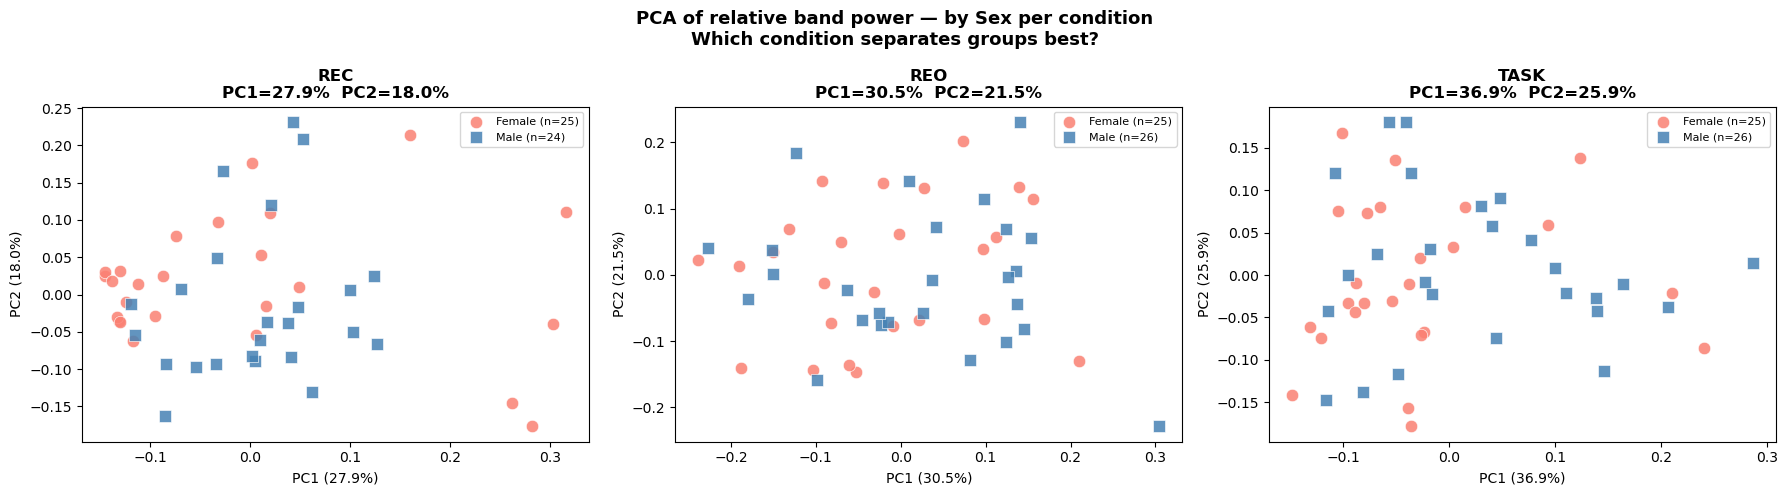

In [14]:
# ============================================================
# CELL F: PCA 2D — visualise group separation per condition
#
# Same visualisation as Part 1, but now with 3 panels:
# one per condition. This shows which condition carries
# the most demographically discriminative EEG information.
# ============================================================

from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sex_colors  = {'Female': 'salmon',    'Male': 'steelblue'}
sex_markers = {'Female': 'o',         'Male': 's'}

for ax, cond in zip(axes, CONDITIONS):
    df  = cond_matrices_rel[cond]
    X   = df[feat_names].values
    y   = df['sex'].values

    pca  = PCA(n_components=2, random_state=42)
    X2   = pca.fit_transform(X)
    expl = pca.explained_variance_ratio_ * 100

    for label in ['Female', 'Male']:
        mask = y == label
        ax.scatter(X2[mask, 0], X2[mask, 1],
                   c=sex_colors[label],
                   marker=sex_markers[label],
                   s=80, edgecolors='white', linewidth=0.5,
                   alpha=0.85, label=f"{label} (n={mask.sum()})")

    ax.set_title(f"{cond}\nPC1={expl[0]:.1f}%  PC2={expl[1]:.1f}%",
                 fontweight='bold')
    ax.set_xlabel(f"PC1 ({expl[0]:.1f}%)")
    ax.set_ylabel(f"PC2 ({expl[1]:.1f}%)")
    ax.legend(fontsize=8)

plt.suptitle("PCA of relative band power — by Sex per condition\n"
             "Which condition separates groups best?",
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# CELL G: Classification per condition
# Targets: sex, age group, handedness
#
# Same setup as Part 1: RF + SVM, 5-fold stratified CV,
# balanced accuracy. Now repeated for each condition separately
# so we can compare which condition is most discriminative.
# ============================================================

from sklearn.ensemble        import RandomForestClassifier
from sklearn.svm             import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing   import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

classifiers = {
    'RF'  : RandomForestClassifier(n_estimators=200, random_state=42),
    'SVM' : SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
}

print("=== Classification per condition (balanced accuracy) ===")
print(f"  Chance levels: Sex=50%  Age=33%  Handedness=50%\n")
print(f"  {'Cond':5s}  {'Task':<14s}  {'RF':>7s}  {'SVM':>7s}")
print("  " + "-" * 40)

all_results = []

for cond in CONDITIONS:
    df = cond_matrices_rel[cond]
    X  = df[feat_names].values

    # ── Labels ──────────────────────────────────────────────
    y_sex = LabelEncoder().fit_transform(df['sex'].values)

    y_age = LabelEncoder().fit_transform(
                pd.cut(df['age'], bins=[0, 25, 40, 100],
                       labels=['Young', 'Middle', 'Older']))

    hand_mask = df['handedness'] != 'Ambidextrous'
    X_hand    = X[hand_mask]
    y_hand    = LabelEncoder().fit_transform(
                    df['handedness'][hand_mask].values)

    tasks = {
        'Sex'        : (X,      y_sex,  2),
        'Age group'  : (X,      y_age,  3),
        'Handedness' : (X_hand, y_hand, 2),
    }

    for task_name, (X_t, y_t, n_cls) in tasks.items():
        chance = 1 / n_cls
        row    = {'condition': cond, 'task': task_name}

        scores_rf  = cross_val_score(classifiers['RF'],  X_t, y_t,
                                     cv=cv, scoring='balanced_accuracy')
        scores_svm = cross_val_score(classifiers['SVM'], X_t, y_t,
                                     cv=cv, scoring='balanced_accuracy')

        row['RF_mean']  = scores_rf.mean()
        row['SVM_mean'] = scores_svm.mean()
        all_results.append(row)

        flag_rf  = " ↑" if scores_rf.mean()  > chance + 0.05 else "  "
        flag_svm = " ↑" if scores_svm.mean() > chance + 0.05 else "  "

        print(f"  {cond:5s}  {task_name:<14s}"
              f"  {scores_rf.mean():.3f}{flag_rf}"
              f"  {scores_svm.mean():.3f}{flag_svm}")
    print()

results_df = pd.DataFrame(all_results)

=== Classification per condition (balanced accuracy) ===
  Chance levels: Sex=50%  Age=33%  Handedness=50%

  Cond   Task                 RF      SVM
  ----------------------------------------
  REC    Sex             0.650 ↑  0.635 ↑
  REC    Age group       0.380    0.480 ↑
  REC    Handedness      0.500    0.500  

  REO    Sex             0.570 ↑  0.607 ↑
  REO    Age group       0.293    0.260  
  REO    Handedness      0.500    0.500  

  TASK   Sex             0.613 ↑  0.557 ↑
  TASK   Age group       0.290    0.363  
  TASK   Handedness      0.500    0.500  



Sexo funciona en las tres condiciones, pero REC es la mejor (RF=0.650, SVM=0.635). Tiene sentido — en reposo con ojos cerrados el EEG refleja la actividad basal del cerebro sin interferencias visuales ni motoras, y ahí las diferencias entre hombres y mujeres son más claras.

Edad solo funciona en REC con SVM (0.480 ↑), y en el resto está por debajo o al nivel del azar. Interesante que REC vuelva a ser la condición más informativa.
Lateralidad es 0.500 en todos los casos — exactamente al azar. Esto ya lo viste en el Part 1 y se confirma aquí: con solo 5 zurdos entre 51 sujetos el clasificador no tiene suficiente señal.

La conclusión parcial más importante: REC es consistentemente la condición más discriminativa, lo cual es contraintuitivo a primera vista — uno esperaría que la tarea activa fuera más informativa, pero la firma de reposo es más estable y característica de cada persona.

In [16]:
# ============================================================
# CELL H: Build the combined feature matrix (REC + REO + TASK)
#
# Hypothesis: the full signature (REC + REO + TASK) is more
# discriminative than any single condition alone.
#
# We concatenate the 70 features from each condition → 210 features.
# Only subjects with all 3 conditions available are included.
# ============================================================

# Subjects present in all 3 conditions
ids_per_cond = {cond: set(cond_matrices_rel[cond]['subject_id'])
                for cond in CONDITIONS}

ids_all_3  = set.intersection(*ids_per_cond.values())
ids_sorted = sorted(ids_all_3)

print(f"Subjects with all 3 conditions: {len(ids_all_3)} / {len(metadata)}")
print(f"Excluded (missing REC): {sorted(set(metadata['subject_id']) - ids_all_3)}\n")

# Align each condition's DataFrame to the same subject order
dfs_renamed = []
for cond in CONDITIONS:
    df      = cond_matrices_rel[cond]
    df_filt = (df[df['subject_id'].isin(ids_all_3)]
                 .set_index('subject_id')
                 .loc[ids_sorted, feat_names])
    # Prefix feature names with condition label
    df_filt = df_filt.rename(columns={f: f"{cond}_{f}" for f in feat_names})
    dfs_renamed.append(df_filt)

# Concatenate horizontally → 210 features per subject
X_combined_cond  = pd.concat(dfs_renamed, axis=1)
feat_names_combined = list(X_combined_cond.columns)

# Add metadata
meta_aligned = (metadata.set_index('subject_id')
                         .loc[ids_sorted][['age', 'sex', 'handedness']])
combined_df  = pd.concat([X_combined_cond, meta_aligned], axis=1).reset_index()

print(f"=== Combined feature matrix ===")
print(f"  Shape    : {combined_df.shape}")
print(f"  Features : {len(feat_names_combined)}  (3 conditions × 70)")
print(f"  Subjects : {len(combined_df)}")

Subjects with all 3 conditions: 49 / 51
Excluded (missing REC): ['M006', 'M015']

=== Combined feature matrix ===
  Shape    : (49, 214)
  Features : 210  (3 conditions × 70)
  Subjects : 49


In [17]:
# ============================================================
# CELL I: Final comparison — individual conditions vs combined
#
# This is the central result of the TFM:
# Does combining REC + REO + TASK improve classification
# over any single condition alone?
#
# Note: all feature sets are evaluated on the same 49 subjects
# so the comparison is fair.
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline       import Pipeline

# Wrap classifiers in a pipeline with scaling
# (especially important for SVM when concatenating features
#  from 3 conditions that may have slightly different scales)
clf_rf  = Pipeline([('scaler', StandardScaler()),
                    ('clf', RandomForestClassifier(n_estimators=200,
                                                   random_state=42))])
clf_svm = Pipeline([('scaler', StandardScaler()),
                    ('clf', SVC(kernel='rbf', C=1.0, gamma='scale',
                                random_state=42))])

# Labels on the 49-subject combined dataset
y_sex  = LabelEncoder().fit_transform(combined_df['sex'].values)

y_age  = LabelEncoder().fit_transform(
             pd.cut(combined_df['age'], bins=[0, 25, 40, 100],
                    labels=['Young', 'Middle', 'Older']))

hand_mask = combined_df['handedness'] != 'Ambidextrous'
y_hand    = LabelEncoder().fit_transform(
                combined_df['handedness'][hand_mask].values)

# Feature sets to compare
feature_sets = {
    'REC only'     : [f"REC_{f}"  for f in feat_names],
    'REO only'     : [f"REO_{f}"  for f in feat_names],
    'TASK only'    : [f"TASK_{f}" for f in feat_names],
    'REC+REO+TASK' : feat_names_combined,
}

task_configs = {
    'Sex'        : (y_sex,  2),
    'Age group'  : (y_age,  3),
    'Handedness' : (y_hand, 2),
}

print("=== Individual conditions vs combined (balanced accuracy) ===")
print(f"  Chance levels: Sex=50%  Age=33%  Handedness=50%\n")
print(f"  {'Features':<16s}  {'Task':<13s}  {'RF':>7s}  {'SVM':>7s}")
print("  " + "-" * 48)

for fs_name, fs_cols in feature_sets.items():
    X_fs = combined_df[fs_cols].values

    for task_name, (y_t, n_cls) in task_configs.items():
        X_t   = X_fs[hand_mask] if task_name == 'Handedness' else X_fs
        chance = 1 / n_cls

        sc_rf  = cross_val_score(clf_rf,  X_t, y_t,
                                 cv=cv, scoring='balanced_accuracy').mean()
        sc_svm = cross_val_score(clf_svm, X_t, y_t,
                                 cv=cv, scoring='balanced_accuracy').mean()

        flag_rf  = " ↑" if sc_rf  > chance + 0.05 else "  "
        flag_svm = " ↑" if sc_svm > chance + 0.05 else "  "

        print(f"  {fs_name:<16s}  {task_name:<13s}"
              f"  {sc_rf:.3f}{flag_rf}  {sc_svm:.3f}{flag_svm}")
    print()

print("  ↑ = more than 5% above chance level")

=== Individual conditions vs combined (balanced accuracy) ===
  Chance levels: Sex=50%  Age=33%  Handedness=50%

  Features          Task                RF      SVM
  ------------------------------------------------
  REC only          Sex            0.650 ↑  0.655 ↑
  REC only          Age group      0.380    0.253  
  REC only          Handedness     0.500    0.500  

  REO only          Sex            0.635 ↑  0.600 ↑
  REO only          Age group      0.300    0.333  
  REO only          Handedness     0.500    0.500  

  TASK only         Sex            0.630 ↑  0.535  
  TASK only         Age group      0.343    0.343  
  TASK only         Handedness     0.500    0.500  

  REC+REO+TASK      Sex            0.590 ↑  0.635 ↑
  REC+REO+TASK      Age group      0.370    0.267  
  REC+REO+TASK      Handedness     0.500    0.500  

  ↑ = more than 5% above chance level


REC solo es igual o mejor que la combinación en casi todos los casos. Para sexo, REC only RF=0.650 vs combinado RF=0.590. Para edad, REC only RF=0.380 vs combinado RF=0.370.


Razones?

- Dimensionalidad: pasar de 70 a 210 features con solo 49 sujetos es demasiado. El clasificador tiene más ruido que señal añadida. 

- REO y TASK no aportan información nueva independiente de REC — las tres condiciones están correlacionadas porque son del mismo cerebro.


1. Sexo es clasificable por encima del azar en las tres condiciones (RF ~0.63-0.65)

2. REC es consistentemente la condición más informativa


3. Lateralidad no es clasificable con este dataset (muy pocos zurdos)

4. Edad solo funciona levemente en REC

## Extras (mejorar sexo con Asimetría y PCA)

In [18]:
# ============================================================
# CELL J: Asymmetry features per condition
#
# Asymmetry index = (Right - Left) / (Right + Left)
# for each hemisphere pair and each frequency band.
#
# In Part 1 this added +4pp on sex classification (0.633 → 0.670).
# Here we compute it separately for REC, REO and TASK.
#
# 7 electrode pairs × 5 bands = 35 asymmetry features per condition
# ============================================================

ELECTRODE_PAIRS = [
    ('AF3', 'AF4'),
    ('F7',  'F8'),
    ('F3',  'F4'),
    ('FC5', 'FC6'),
    ('T7',  'T8'),
    ('P7',  'P8'),
    ('O1',  'O2'),
]

def compute_asymmetry_features(X_rel, feat_names, pairs=ELECTRODE_PAIRS, bands=BANDS):
    """
    Computes hemispheric asymmetry index for each electrode pair and band.
    Asymmetry = (Right - Left) / (Right + Left)
    Values in [-1, 1]: negative = left dominant, positive = right dominant.

    Parameters
    ----------
    X_rel      : np.ndarray, shape (n_subjects, n_features) — relative PSD
    feat_names : list of feature name strings e.g. ['AF3_delta', ...]

    Returns
    -------
    X_asym     : np.ndarray, shape (n_subjects, n_pairs * n_bands)
    asym_names : list of feature name strings
    """
    asym_features = []
    asym_names    = []

    for left_ch, right_ch in pairs:
        for band in bands.keys():
            left_idx  = feat_names.index(f"{left_ch}_{band}")
            right_idx = feat_names.index(f"{right_ch}_{band}")

            left_val  = X_rel[:, left_idx]
            right_val = X_rel[:, right_idx]

            asym = (right_val - left_val) / (right_val + left_val + 1e-10)
            asym_features.append(asym)
            asym_names.append(f"asym_{left_ch}_{right_ch}_{band}")

    return np.column_stack(asym_features), asym_names


# ── Compute asymmetry for each condition and build extended matrices ──

cond_matrices_full = {}   # PSD relative + asymmetry per condition

print("=== Asymmetry features per condition ===\n")

for cond in CONDITIONS:
    df    = cond_matrices_rel[cond]
    X_rel = df[feat_names].values

    X_asym, asym_names = compute_asymmetry_features(X_rel, feat_names)

    # Combined: relative PSD (70) + asymmetry (35) = 105 features
    X_full      = np.hstack([X_rel, X_asym])
    full_names  = feat_names + asym_names

    # Store as DataFrame
    df_full = pd.DataFrame(X_full, columns=full_names)
    df_full.insert(0, 'subject_id', df['subject_id'].values)
    df_full.insert(1, 'condition',  cond)
    df_full = df_full.merge(metadata, on='subject_id')

    cond_matrices_full[cond] = {
        'df'        : df_full,
        'X'         : X_full,
        'feat_names': full_names,
        'asym_names': asym_names,
    }

    print(f"  {cond:5s}  PSD={len(feat_names)}  +asym={len(asym_names)}"
          f"  total={len(full_names)}  subjects={len(df_full)}")

asym_names_ref = asym_names   # save for later use
full_names_ref = full_names

=== Asymmetry features per condition ===

  REC    PSD=70  +asym=35  total=105  subjects=49
  REO    PSD=70  +asym=35  total=105  subjects=51
  TASK   PSD=70  +asym=35  total=105  subjects=51


In [19]:
# ============================================================
# CELL K: Classification with PSD + Asymmetry per condition
#
# Comparing two feature sets per condition:
#   - PSD only       (70 features) — already done in Cell G
#   - PSD + Asymmetry (105 features) — new
#
# Expect asymmetry to help most on Sex, as in Part 1.
# ============================================================

print("=== PSD only vs PSD + Asymmetry per condition (Sex) ===")
print(f"  Chance level: 50%\n")
print(f"  {'Cond':5s}  {'Features':<18s}  {'RF':>7s}  {'SVM':>7s}")
print("  " + "-" * 42)

for cond in CONDITIONS:
    df_full   = cond_matrices_full[cond]['df']
    X_full    = cond_matrices_full[cond]['X']
    X_psd     = cond_matrices_rel[cond][feat_names].values
    y_sex     = LabelEncoder().fit_transform(df_full['sex'].values)

    for label, X_t in [('PSD only', X_psd), ('PSD + Asymmetry', X_full)]:
        sc_rf  = cross_val_score(classifiers['RF'],  X_t, y_sex,
                                 cv=cv, scoring='balanced_accuracy').mean()
        sc_svm = cross_val_score(classifiers['SVM'], X_t, y_sex,
                                 cv=cv, scoring='balanced_accuracy').mean()

        flag_rf  = " ↑" if sc_rf  > 0.55 else "  "
        flag_svm = " ↑" if sc_svm > 0.55 else "  "

        print(f"  {cond:5s}  {label:<18s}"
              f"  {sc_rf:.3f}{flag_rf}  {sc_svm:.3f}{flag_svm}")
    print()

=== PSD only vs PSD + Asymmetry per condition (Sex) ===
  Chance level: 50%

  Cond   Features                 RF      SVM
  ------------------------------------------
  REC    PSD only            0.650 ↑  0.635 ↑
  REC    PSD + Asymmetry     0.690 ↑  0.670 ↑

  REO    PSD only            0.570 ↑  0.607 ↑
  REO    PSD + Asymmetry     0.573 ↑  0.647 ↑

  TASK   PSD only            0.613 ↑  0.557 ↑
  TASK   PSD + Asymmetry     0.653 ↑  0.650 ↑



In [21]:
# ============================================================
# CELL L: PCA + classification on combined REC+REO+TASK
#
# Problem in Cell I: combining 3 conditions → 315 features
# (105 per condition) with only 49 subjects hurts performance.
# This is the curse of dimensionality: too many features,
# too few samples.
#
# Solution: PCA before the classifier compresses the 315
# features into a smaller set of uncorrelated components
# that capture most of the variance.
#
# Why these n_components values?
#   5-fold CV → each training fold has ~39 samples
#   PCA requires n_components <= n_samples in the fold
#   Safe maximum ≈ 35, so we test [5, 10, 20, 30]
#   This covers the range from 39.7% to 93.2% variance explained
#   and lets us find the sweet spot before overfitting kicks in.
# ============================================================

from sklearn.decomposition import PCA
from sklearn.pipeline      import Pipeline
from sklearn.preprocessing import StandardScaler

# ── Build the 315-feature combined matrix (49 subjects) ──────────
dfs_full_renamed = []
for cond in CONDITIONS:
    df_f    = cond_matrices_full[cond]['df']
    fn      = cond_matrices_full[cond]['feat_names']
    df_filt = (df_f[df_f['subject_id'].isin(ids_all_3)]
                  .set_index('subject_id')
                  .loc[ids_sorted, fn])
    df_filt = df_filt.rename(columns={f: f"{cond}_{f}" for f in fn})
    dfs_full_renamed.append(df_filt)

X_combined_full = pd.concat(dfs_full_renamed, axis=1).values  # (49, 315)

# Labels for the 49 subjects
y_sex_49 = LabelEncoder().fit_transform(combined_df['sex'].values)

print("=== PCA + classification on REC+REO+TASK combined ===")
print(f"  315 features (3 × 105) → PCA → classifier")
print(f"  Target: Sex  |  Chance: 50%\n")
print(f"  {'n_components':<15s}  {'RF':>7s}  {'SVM':>7s}  {'var_explained':>14s}")
print("  " + "-" * 48)

n_components_list = [5, 10, 20, 30]

for n in n_components_list:
    pipe_rf  = Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=n, random_state=42)),
        ('clf',    RandomForestClassifier(n_estimators=200, random_state=42))
    ])
    pipe_svm = Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=n, random_state=42)),
        ('clf',    SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))
    ])

    sc_rf  = cross_val_score(pipe_rf,  X_combined_full, y_sex_49,
                             cv=cv, scoring='balanced_accuracy').mean()
    sc_svm = cross_val_score(pipe_svm, X_combined_full, y_sex_49,
                             cv=cv, scoring='balanced_accuracy').mean()

    # Variance explained: fit once on full data for reference only
    # (not used in CV — just to report how much info each n captures)
    scaler  = StandardScaler().fit(X_combined_full)
    pca_ref = PCA(n_components=n, random_state=42).fit(
                  scaler.transform(X_combined_full))
    var_exp = pca_ref.explained_variance_ratio_.sum() * 100

    flag_rf  = " ↑" if sc_rf  > 0.55 else "  "
    flag_svm = " ↑" if sc_svm > 0.55 else "  "

    print(f"  {str(n):<15s}  {sc_rf:.3f}{flag_rf}  {sc_svm:.3f}{flag_svm}"
          f"  {var_exp:.1f}%")

print(f"\n  Reference — best single condition:")
print(f"    REC + Asymmetry   RF : 0.690")
print(f"    REC + Asymmetry   SVM: 0.670")

=== PCA + classification on REC+REO+TASK combined ===
  315 features (3 × 105) → PCA → classifier
  Target: Sex  |  Chance: 50%

  n_components          RF      SVM   var_explained
  ------------------------------------------------
  5                0.670 ↑  0.670 ↑  39.7%
  10               0.675 ↑  0.695 ↑  60.7%
  20               0.595 ↑  0.655 ↑  83.4%
  30               0.635 ↑  0.655 ↑  93.2%

  Reference — best single condition:
    REC + Asymmetry   RF : 0.690
    REC + Asymmetry   SVM: 0.670


## Intentar mejorar la clasificacion de la edad

Estrategias: 

1. Reagrupar en solo 2 clases en vez de 3. En lugar de Young/Middle/Older, hacer simplemente Young (<30) vs Older (≥30). Quedarían grupos más equilibrados y el problema pasa de 33% de azar a 50%, más manejable.

2. Features específicas de edad. La literatura dice que con la edad el alpha decrece y el theta aumenta, especialmente en frontal. Podríamos construir un ratio theta/alpha por canal frontal — una feature muy dirigida a lo que sabemos que cambia con la edad.

3. Slowing index: con la edad el pico de frecuencia individual (IAF, Individual Alpha Frequency) se desplaza hacia frecuencias más bajas. Es uno de los biomarcadores de edad más estudiados en EEG.

In [22]:
# ============================================================
# CELL M: Age classification — two targeted improvements
#
# Problem: 3-class age grouping with only 6 "Older" subjects
# is statistically unreliable (chance = 33%).
#
# Attempt 1: binary split Young (<30) vs Older (>=30)
#   → more balanced classes, chance = 50%
#
# Attempt 2: theta/alpha ratio features per frontal channel
#   → literature shows theta increases and alpha decreases
#     with age, especially in frontal regions
#
# Both are tested on REC only (best condition for age in Cell G)
# and on the combined REC+REO+TASK + PCA(10) pipeline.
# ============================================================

# ── Check class distribution for both splits ─────────────────────
df_rec = cond_matrices_rel['REC']

age_3class = pd.cut(df_rec['age'], bins=[0, 25, 40, 100],
                    labels=['Young (<25)', 'Middle (25-40)', 'Older (>40)'])
age_2class = pd.cut(df_rec['age'], bins=[0, 30, 100],
                    labels=['Young (<30)', 'Older (>=30)'])

print("=== Age group distributions (REC, 49 subjects) ===\n")
print("  3-class split (original):")
for label, count in age_3class.value_counts().sort_index().items():
    print(f"    {label}: {count}")

print("\n  2-class split (new):")
for label, count in age_2class.value_counts().sort_index().items():
    print(f"    {label}: {count}")

# ── Attempt 1: binary age classification ─────────────────────────
y_age2 = LabelEncoder().fit_transform(age_2class)

print("\n=== Attempt 1: binary age (Young <30 vs Older >=30) ===")
print(f"  Chance level: 50%\n")
print(f"  {'Condition':<8s}  {'Features':<18s}  {'RF':>7s}  {'SVM':>7s}")
print("  " + "-" * 44)

for cond in CONDITIONS:
    df_c  = cond_matrices_full[cond]['df']
    X_psd = cond_matrices_rel[cond][feat_names].values
    X_ful = cond_matrices_full[cond]['X']

    # Recompute 2-class labels for this condition's subjects
    y_a2  = LabelEncoder().fit_transform(
                pd.cut(df_c['age'], bins=[0, 30, 100],
                       labels=['Young', 'Older']))

    for label, X_t in [('PSD only', X_psd), ('PSD + Asym', X_ful)]:
        sc_rf  = cross_val_score(classifiers['RF'],  X_t, y_a2,
                                 cv=cv, scoring='balanced_accuracy').mean()
        sc_svm = cross_val_score(classifiers['SVM'], X_t, y_a2,
                                 cv=cv, scoring='balanced_accuracy').mean()
        flag_rf  = " ↑" if sc_rf  > 0.55 else "  "
        flag_svm = " ↑" if sc_svm > 0.55 else "  "
        print(f"  {cond:<8s}  {label:<18s}"
              f"  {sc_rf:.3f}{flag_rf}  {sc_svm:.3f}{flag_svm}")
    print()

# ── Attempt 2: theta/alpha ratio features ────────────────────────
FRONTAL_CHANNELS = ['AF3', 'AF4', 'F7', 'F8', 'F3', 'F4']

def compute_theta_alpha_ratio(df, feat_names):
    """
    Computes theta/alpha ratio for each frontal channel.
    Higher ratio = more theta relative to alpha = older brain signature.
    Returns array (n_subjects, n_frontal_channels) and feature names.
    """
    ratios, names = [], []
    for ch in FRONTAL_CHANNELS:
        theta_idx = feat_names.index(f"{ch}_theta")
        alpha_idx = feat_names.index(f"{ch}_alpha")
        theta_val = df[feat_names].values[:, theta_idx]
        alpha_val = df[feat_names].values[:, alpha_idx]
        ratio     = theta_val / (alpha_val + 1e-10)
        ratios.append(ratio)
        names.append(f"ta_ratio_{ch}")
    return np.column_stack(ratios), names


print("=== Attempt 2: PSD + Asymmetry + Theta/Alpha ratio ===")
print(f"  Chance level: 50% (binary split)\n")
print(f"  {'Condition':<8s}  {'Features':<25s}  {'RF':>7s}  {'SVM':>7s}")
print("  " + "-" * 52)

for cond in CONDITIONS:
    df_c   = cond_matrices_full[cond]['df']
    X_full = cond_matrices_full[cond]['X']
    fn     = cond_matrices_full[cond]['feat_names']

    X_ta, ta_names = compute_theta_alpha_ratio(df_c, feat_names)
    X_extended     = np.hstack([X_full, X_ta])   # 105 + 6 = 111 features

    y_a2 = LabelEncoder().fit_transform(
               pd.cut(df_c['age'], bins=[0, 30, 100],
                      labels=['Young', 'Older']))

    for label, X_t in [('PSD + Asym', X_full),
                        ('PSD + Asym + TA ratio', X_extended)]:
        sc_rf  = cross_val_score(classifiers['RF'],  X_t, y_a2,
                                 cv=cv, scoring='balanced_accuracy').mean()
        sc_svm = cross_val_score(classifiers['SVM'], X_t, y_a2,
                                 cv=cv, scoring='balanced_accuracy').mean()
        flag_rf  = " ↑" if sc_rf  > 0.55 else "  "
        flag_svm = " ↑" if sc_svm > 0.55 else "  "
        print(f"  {cond:<8s}  {label:<25s}"
              f"  {sc_rf:.3f}{flag_rf}  {sc_svm:.3f}{flag_svm}")
    print()

=== Age group distributions (REC, 49 subjects) ===

  3-class split (original):
    Young (<25): 22
    Middle (25-40): 21
    Older (>40): 6

  2-class split (new):
    Young (<30): 35
    Older (>=30): 14

=== Attempt 1: binary age (Young <30 vs Older >=30) ===
  Chance level: 50%

  Condition  Features                 RF      SVM
  --------------------------------------------
  REC       PSD only            0.569 ↑  0.533  
  REC       PSD + Asym          0.583 ↑  0.500  

  REO       PSD only            0.486    0.500  
  REO       PSD + Asym          0.521    0.500  

  TASK      PSD only            0.482    0.500  
  TASK      PSD + Asym          0.482    0.500  

=== Attempt 2: PSD + Asymmetry + Theta/Alpha ratio ===
  Chance level: 50% (binary split)

  Condition  Features                        RF      SVM
  ----------------------------------------------------
  REC       PSD + Asym                 0.583 ↑  0.500  
  REC       PSD + Asym + TA ratio      0.602 ↑  0.500  

  REO

In [23]:
# ============================================================
# CELL N: Individual Alpha Frequency (IAF) as age biomarker
#
# IAF = the frequency at which alpha power peaks (8-13 Hz).
# Well-established finding in neuroscience:
#   Young brains  → IAF ~10-11 Hz
#   Older brains  → IAF ~8-9 Hz  (alpha slowing with age)
#
# This is more specific than band power — it captures WHERE
# the alpha peak sits, not just how much alpha there is.
#
# We extract IAF from occipital channels (O1, O2) during REC,
# since alpha is strongest with eyes closed at occipital sites.
#
# Combined feature vector per subject:
#   PSD (70) + Asymmetry (35) + TA ratio (6) + IAF (2) = 113
# ============================================================

from scipy.signal import welch as sp_welch

def compute_iaf(segment, sfreq=SFREQ, channels=['O1', 'O2'],
                fmin=7.0, fmax=14.0):
    """
    Computes Individual Alpha Frequency (IAF) per channel.
    IAF = frequency of peak power within the extended alpha range.

    Parameters
    ----------
    segment  : np.ndarray, shape (14, n_samples)
    channels : list of channel names to compute IAF on
    fmin/fmax: search range in Hz (slightly wider than 8-13
               to catch edge cases in older subjects)

    Returns
    -------
    iaf_values : list of float, one per channel
    iaf_names  : list of feature name strings
    """
    iaf_values = []
    iaf_names  = []

    for ch_name in channels:
        ch_idx = EEG_CHANNELS.index(ch_name)
        freqs, psd = sp_welch(segment[ch_idx, :], fs=sfreq,
                              nperseg=min(256, segment.shape[1]))
        # Find peak within alpha range
        alpha_mask = (freqs >= fmin) & (freqs <= fmax)
        peak_freq  = freqs[alpha_mask][np.argmax(psd[alpha_mask])]
        iaf_values.append(peak_freq)
        iaf_names.append(f"iaf_{ch_name}")

    return iaf_values, iaf_names


# ── Compute IAF for all subjects using REC segment ───────────────
iaf_records = []

for _, row in metadata.iterrows():
    sid      = row['subject_id']
    edf_path = find_edf(sid, session='G10')
    if edf_path is None:
        continue
    try:
        segs = extract_condition_segments(edf_path)
        if segs['REC'] is None:
            continue
        iaf_vals, iaf_names = compute_iaf(segs['REC'])
        iaf_records.append([sid] + iaf_vals)
    except Exception:
        continue

iaf_df = pd.DataFrame(iaf_records, columns=['subject_id'] + iaf_names)
iaf_df = iaf_df.merge(metadata, on='subject_id')

print("=== IAF computed for all subjects ===\n")
print(f"  Subjects: {len(iaf_df)}")
print(f"\n  {'subject_id':8s}  {'IAF O1':>8s}  {'IAF O2':>8s}  {'age':>5s}")
print("  " + "-" * 34)
for _, r in iaf_df.iterrows():
    print(f"  {r['subject_id']:8s}  {r['iaf_O1']:>8.2f}  "
          f"{r['iaf_O2']:>8.2f}  {r['age']:>5.0f}")

=== IAF computed for all subjects ===

  Subjects: 49

  subject_id    IAF O1    IAF O2    age
  ----------------------------------
  F001         11.00     11.00     22
  F002         13.00      7.00     26
  F003         11.00     12.00     27
  F004         11.00     10.00     20
  F005          9.50      9.50     24
  F006          7.50      7.50     39
  F007         10.50     10.50     40
  F008          9.50      9.50     45
  F009         13.50     12.50     38
  F010         11.00     11.50     22
  F011         10.00     10.00     28
  F012         10.50     10.50     25
  F013         10.00     10.00     56
  F014         12.00     13.50     40
  F015         11.50     12.50     24
  F016         12.50     12.50     22
  F017         11.50     11.50     27
  F018         11.50     11.50     16
  F019         11.00     11.00     59
  F020          9.50      9.50     31
  F021         13.00     10.00     29
  F022         10.50     10.50     26
  F023         11.00     11.00  

In [24]:
# ============================================================
# CELL O: Classification with IAF added to feature vector
#
# Adding IAF (2 features: O1 + O2) to the best pipeline so far:
# PSD (70) + Asymmetry (35) + TA ratio (6) + IAF (2) = 113 features
# Tested on REC only (best condition for age throughout).
# Binary split: Young (<30) vs Older (>=30)
# ============================================================

# ── Build extended feature matrix for REC ────────────────────────
df_rec_full = cond_matrices_full['REC']['df']
X_rec_full  = cond_matrices_full['REC']['X']          # (49, 105)

# TA ratio features
X_ta_rec, ta_names = compute_theta_alpha_ratio(df_rec_full, feat_names)

# IAF features — align to same subjects as REC
iaf_aligned = (iaf_df.set_index('subject_id')
                      .loc[df_rec_full['subject_id'].values, iaf_names]
                      .values)                         # (49, 2)

# Stack everything
X_113 = np.hstack([X_rec_full, X_ta_rec, iaf_aligned])  # (49, 113)

# Labels
y_age2_rec = LabelEncoder().fit_transform(
                 pd.cut(df_rec_full['age'], bins=[0, 30, 100],
                        labels=['Young', 'Older']))

print("=== Age classification — REC, all feature combinations ===")
print(f"  Binary split: Young (<30) vs Older (>=30)  |  Chance: 50%\n")
print(f"  {'Features':<30s}  {'n_feat':>6s}  {'RF':>7s}  {'SVM':>7s}")
print("  " + "-" * 56)

feature_sets = {
    'PSD only'              : (X_rec_full[:, :70],  70),
    'PSD + Asym'            : (X_rec_full,          105),
    'PSD + Asym + TA ratio' : (np.hstack([X_rec_full, X_ta_rec]), 111),
    'PSD + Asym + TA + IAF' : (X_113,               113),
}

for label, (X_t, n_f) in feature_sets.items():
    sc_rf  = cross_val_score(classifiers['RF'],  X_t, y_age2_rec,
                             cv=cv, scoring='balanced_accuracy').mean()
    sc_svm = cross_val_score(classifiers['SVM'], X_t, y_age2_rec,
                             cv=cv, scoring='balanced_accuracy').mean()
    flag_rf  = " ↑" if sc_rf  > 0.55 else "  "
    flag_svm = " ↑" if sc_svm > 0.55 else "  "
    print(f"  {label:<30s}  {n_f:>6d}  "
          f"{sc_rf:.3f}{flag_rf}  {sc_svm:.3f}{flag_svm}")

=== Age classification — REC, all feature combinations ===
  Binary split: Young (<30) vs Older (>=30)  |  Chance: 50%

  Features                        n_feat       RF      SVM
  --------------------------------------------------------
  PSD only                            70  0.569 ↑  0.533  
  PSD + Asym                         105  0.583 ↑  0.500  
  PSD + Asym + TA ratio              111  0.602 ↑  0.500  
  PSD + Asym + TA + IAF              113  0.583 ↑  0.500  
